# **Class Imbalance Lab 1**

### Authors:  Mariel Concepcion, Lorenzo De Villa, Bingbong Manglicmot, Caitlin Sebastian, JF Viray
### Learning Team: 7
---

In [18]:
# Core
# Utils
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import ADASYN, SMOTE, KMeansSMOTE, RandomOverSampler

# Imbalanced learning
from imblearn.under_sampling import RandomUnderSampler, TomekLinks


# Preprocessing & Pipeline
from sklearn.model_selection import (
    train_test_split,
)

from model import FraudDetector

# Set up a fig counter
fig_count = 2

# **1. Executive Summary**

CreditByte is a mid-sized financial services company, which struggles with fraud since criminals bypass traditional rule-based systems.  For example, many fraudulent transactions are small in amount, making them difficult to flag with just a simple threshold check. The goal of this study is to help improve the true classification of fraudulent transactions in order to minimize expenditures. Random Forest model was used to improve fraud detection with particular attention to the heavy class imbalance between the 305 fraudulent and 180,149 non-fraudulent samples. 

Among the various methods tested, Random Undersampling achieved the highest recall of 93%, but this came at the cost of terrible precision (53%), leading to many non-fraudulent transactions being incorrectly flagged. By contrast, SMOTE delivered a lower recall of 91% but significantly improved precision to 94%, representing a more balanced trade-off between recall and precision. In terms of monetary savings, SMOTE is a more practical and business-friendly choice since you get to save 3,341; unlike random undersampling that has a loss of 238,896. The team further built on SMOTE by combining it with other strategies but only improved marginally. Overall, these findings highlight machine learning as a stronger defense against fraud for CreditByte than just thresholding. Moving forward, future studies should expand on these results by exploring alternative models (e.g., gradient boosting or deep learning), and testing ensemble approaches and real-time detection systems to ensure CreditByte remains adaptive to evolving fraud tactics. Additionally, research could incorporate explainability tools like SHAP or LIME to ensure proper interpretability for stakeholders. 

(The project environment is set up with Python version 3.12.8.)

---

# **2. Introduction** 
In the financial industry, credit card fraud has become a pressing issue, with consumers losing $12.5 billion in 2024 alone (Federal Trade Commission, 2025). To counter this, financial services have been utilizing machine learning to detect fraud, thereby saving both consumers and providers from losses. However, CreditByte, a financial services company, has continued to rely on traditional rule-based systems. These methods, such as flagging questionably large transactions, are no longer reliable. Such strategies make these threshold-based methods ineffective and emphasizes the need for more intelligent and data-driven approaches. 

This study is guided by two main objectives. First being to understand why older methods of thresholding and flagging unusual transaction amounts are ineffective. In doing so, exploratory data analysis (EDA) will be used to examine patterns that differentiate fraudulent from non-fraudulent transactions. The other objective is to improve the prediction of fraudulent transactions. This can be done by evaluating different rebalancing strategies (oversampling, undersampling, hybrid approaches, class weights, etc.), while maintaining a Random Forest classifier with 500 estimators fixed as a controlled baseline. 

In applying the various methods to handle class imbalance for CreditByte's fraud detection, this study strives to build a model that both improves technical metrics such as precision, recall, and F1-score, as well as contribute to better business decisions to strengthen outcomes like detection rates. Ultimately, this study aims to support that addressing imbalance directly can provide CreditByte stronger and more efficient methods against adaptive fraud strategies. 

---

# **3. Methodology**



# **4. Results and Discussion**


## **4.1 Exploratory Data Analysis**


Our overall objectives are:
1. To understand why the older methods of thresholding and flagging unusual transaction amounts are no longer effective.
2. To improve the prediction of fraudulent transactions.

For the first objective, we will examine patterns that differentiate fraudulent transactions from non-fraudulent ones by doing an EDA.
For the second objective, we will evaluate different sampling strategies and class weighting while keeping the Random Forest classifier with 500 estimators as a controlled variable. This is because Mara has already established that baseline, and our goal is to build on top of her work.

In [19]:
df = pd.read_csv("historical.csv")

# Drop tid because it is just a unique id
df = df.drop(columns=["tid"])

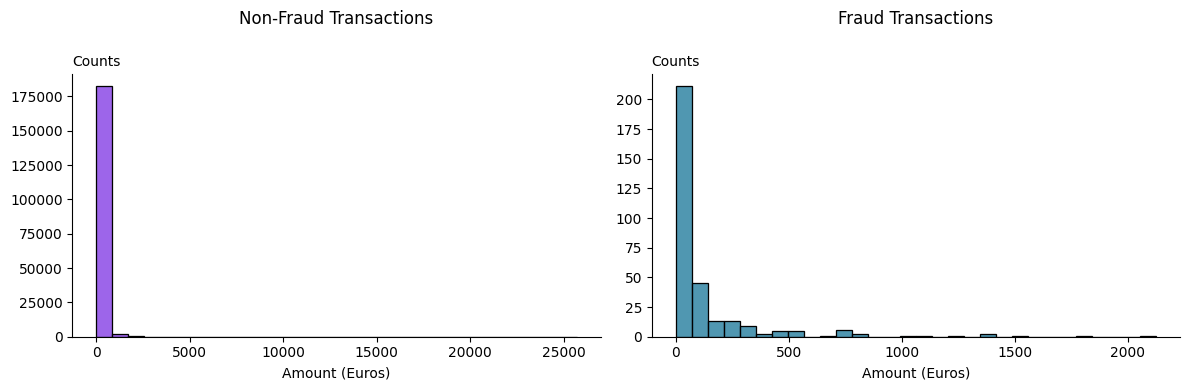

In [20]:
# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Non-Fraud (outcome = 0)
sns.histplot(
    data=df[df['outcome'] == 0],
    x="Amount",
    bins=30,
    color="#7c31e4",
    ax=axes[0]
)
axes[0].set_title("Non-Fraud Transactions\n\n")
axes[0].set_xlabel("Amount (Euros)")
axes[0].set_ylabel("Counts", rotation=0, ha='left')
axes[0].yaxis.set_label_coords(0, 1.02)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Fraud (outcome = 1)
sns.histplot(
    data=df[df['outcome'] == 1],
    x="Amount",
    bins=30,
    color="#157497",
    ax=axes[1]
)
axes[1].set_title("Fraud Transactions\n\n")
axes[1].set_xlabel("Amount (Euros)")
axes[1].set_ylabel("Counts", rotation=0, ha='left')
axes[1].yaxis.set_label_coords(0, 1.02)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f'figures/{fig_count:02d}_histograms.png', dpi=300, bbox_inches='tight')
fig_count += 1
plt.show()


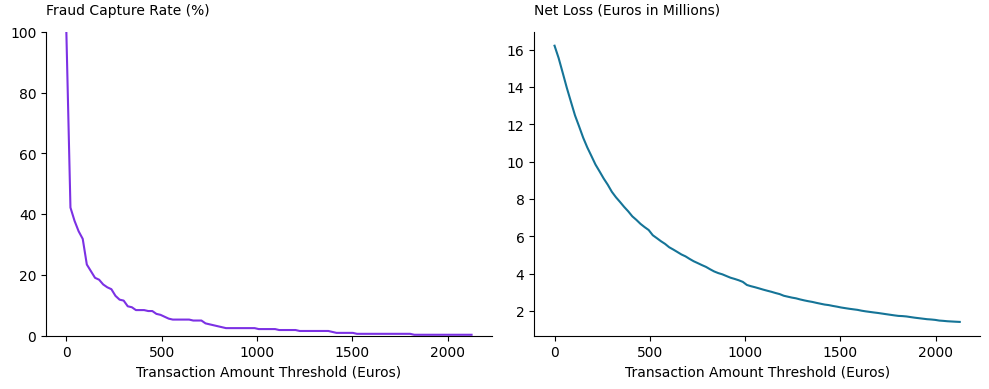

In [21]:
# Load data
y_actual = df['outcome']
is_fraud = y_actual == 1

# Threshold function
def thresholds_fraud(amounts, threshold):
    return (amounts >= threshold).astype(int)

# Define thresholds to test
min_fraud_amount = df.loc[is_fraud, 'Amount'].min()
max_fraud_amount = df.loc[is_fraud, 'Amount'].max()
thresholds = np.linspace(min_fraud_amount, max_fraud_amount, 100)

# Store metrics
fraud_capture_rates = []
detection_rates = []
net_savings = []

for t in thresholds:
    y_pred = thresholds_fraud(df['Amount'], t)
    
    # Fraud Capture Rate
    true_positives = ((y_pred == 1) & (y_actual == 1)).sum()
    actual_positives = (y_actual == 1).sum()
    fraud_capture_rate = true_positives / actual_positives if actual_positives > 0 else 0
    fraud_capture_rates.append(fraud_capture_rate)
    
    # Precision
    predicted_positives = (y_pred == 1).sum()
    precision = true_positives / predicted_positives if predicted_positives > 0 else 0
    detection_rates.append(precision)
    
    # Net Savings Score
    true_positives_mask = (y_pred == 1) & (y_actual == 1)
    false_positives_mask = (y_pred == 1) & (y_actual == 0)
    tp_sum = df.loc[true_positives_mask, 'Amount'].sum()
    fp_sum = df.loc[false_positives_mask, 'Amount'].sum()
    net_savings.append(tp_sum - fp_sum)

# Scale net savings to millions
net_savings_millions = np.array(net_savings) / 1e6
fraud_capture_rates_percent = np.array(fraud_capture_rates) * 100

# Create combined figure with 3 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Fraud Capture Rate
axes[0].plot(thresholds, fraud_capture_rates_percent, color='#7c31e4')
axes[0].set_ylabel('Fraud Capture Rate (%)', rotation=0, ha='left')
axes[0].set_ylim(0, 100)

# Net Savings Score in Millions
axes[1].plot(thresholds, -net_savings_millions, color='#157497')
axes[1].set_ylabel('Net Loss (Euros in Millions)', rotation=0, ha='left')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Transaction Amount Threshold (Euros)')
    ax.yaxis.set_label_coords(0, 1.05)

plt.tight_layout()
plt.savefig(f'figures/{fig_count:02d}_thresholds.png', dpi=300, bbox_inches='tight')
fig_count += 1
plt.show()



<b><i> Figure 2.</b> Box Plot of Transaction Amounts by Outcome </i>

In contrast to using only transaction amounts, we can also look at the principal components. Figure 3 shows little to no correlation among non-fraudulent transactions while fraudulent transactions display stronger relationships in the heatmap. This suggests that fraud data contains patterns that machine learning can exploit to improve prediction.

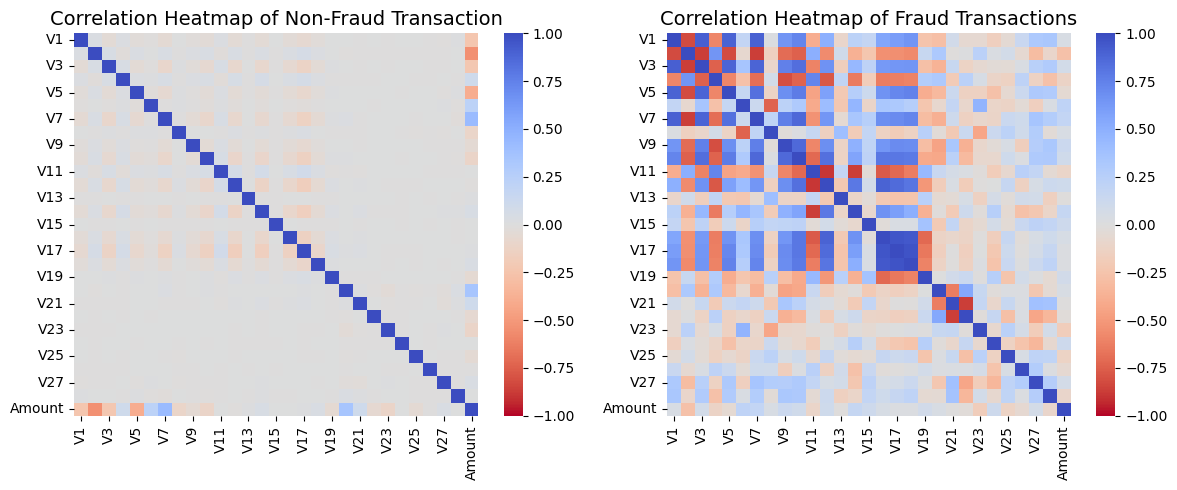

In [22]:
# Split datasets
is_fraud = df["outcome"] == 1
df_0 = df[~is_fraud]
df_1 = df[is_fraud]

# Compute correlation matrices
corr_0 = df_0.iloc[:, :-1].corr()
corr_1 = df_1.iloc[:, :-1].corr()

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    corr_0,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[0],
)
axes[0].set_title("Correlation Heatmap of Non-Fraud Transaction", 
                  fontsize=14)

sns.heatmap(
    corr_1,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[1],
)
axes[1].set_title("Correlation Heatmap of Fraud Transactions", fontsize=14)

plt.tight_layout()
plt.show()

<b><i> Figure 3 </b> Correlation Heatmap of Non-Fraud and Fraud Transactions </i>

To further visualize the patterns in fraud data, two scatterplots were made in Figure 4 to show the relationships of V1 to V3 (a) and V18 to V16 (b). These plots further emphasizes how fraud transactions (red) cluster differently from non-fraud ones (blue), suggesting that certain components capture meaningful distinctions between the two classes.

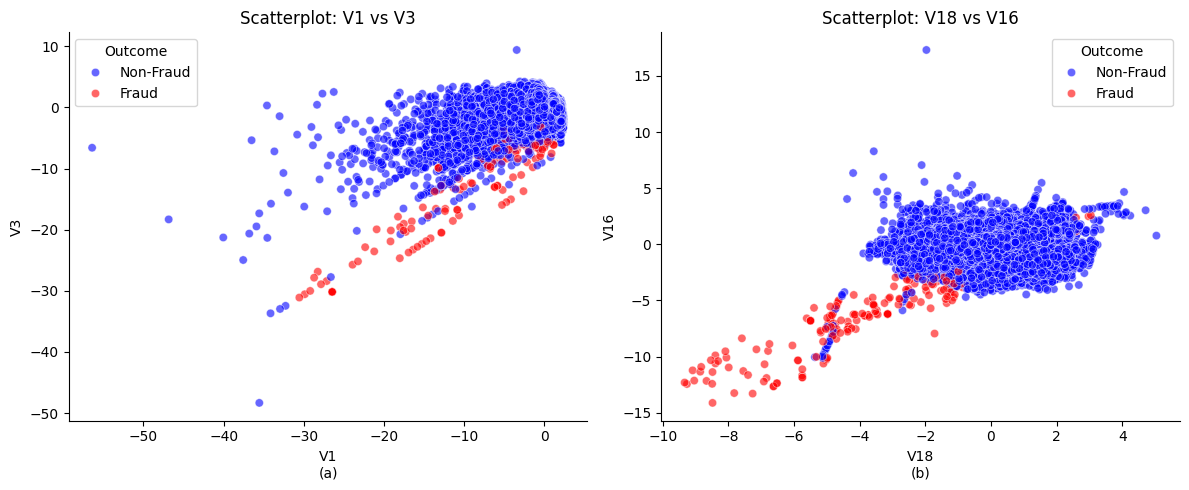

In [23]:
plt.figure(figsize=(12, 5))

# V1 vs V3
plt.subplot(1, 2, 1)
ax1 = sns.scatterplot(
    data=df, x="V1", y="V3", hue="outcome", alpha=0.6, 
    palette={0: "blue", 1: "red"}
)
legend1 = ax1.legend_
legend1.set_title("Outcome")
for t, new_label in zip(legend1.texts, ["Non-Fraud", "Fraud"]):
    t.set_text(new_label)
plt.title("Scatterplot: V1 vs V3")
ax1.set_xlabel("V1\n(a)")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


# V18 vs V16
plt.subplot(1, 2, 2)
ax2 = sns.scatterplot(
    data=df, x="V18", y="V16", hue="outcome", alpha=0.6, 
    palette={0: "blue", 1: "red"}
)
legend2 = ax2.legend_
legend2.set_title("Outcome")
for t, new_label in zip(legend2.texts, ["Non-Fraud", "Fraud"]):
    t.set_text(new_label)
plt.title("Scatterplot: V18 vs V16")
ax2.set_xlabel("V18\n(b)")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 2. To improve the prediction of fraudulent transactions.

## **4.2 Handle Class Imbalance**
### **4.2.1 Traditional Rebalancing Methods**
Let us now define the metrics that we shall use to optimize the model. We have:
1. Detection Rate
    * This asks, "Out of all transactions, how well does the model is at correctly identifying both fraud and non-fraud overall, where both are equally important?"

2. Fraud Capture Rate
    * This asks, "Out of all the fraud cases, how many did the model actually catch?"

3. Net Value Gained  - 
    * This asks, "How much money does the model helps save (by catching fraud)?"

Because we can only use one metric to optimize the model, we choose the Fraud Capture Rate to optimize since our second objective is to improve the prediction of fraudulent transactions. This metric aligns closely with CreditByte’s business-critical goal of reducing credit card fraud. For additional business context, we also report Net Value Gained to reflect the monetary impact. The technical definitions of all metrics used are provided below.

#### 1. **Detection Rate which is the same as Macro Recall**  
Detection Rate:  

$$
\text{Detection Rate} = \frac{1}{2} \bigg(\frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}} + \frac{TP_{\text{nonfraud}}}{TP_{\text{nonfraud}} + FN_{\text{nonfraud}}} \bigg)
$$

where  
- $n_{\text{fraud}}$ = number of fraud samples  
- $n_{\text{nonfraud}}$ = number of non-fraud samples  
- $N$ = total number of samples  
- $TP_{\text{fraud}}$ = fraud cases correctly identified  
- $FN_{\text{fraud}}$ = fraud cases missed  
- $TP_{\text{nonfraud}}$ = non-fraud cases correctly identified  
- $FN_{\text{nonfraud}}$ = non-fraud cases missed  


#### 2. **Fraud Capture Rate, which is the same as Recall for Fraud Transactions**  

$$
\text{Fraud Capture Rate} = \frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}}
$$  

where  
- $TP_{\text{fraud}}$ = fraud cases correctly identified  
- $FN_{\text{fraud}}$ = fraud cases missed  


#### 3. **Net Value**  

$$
\text{Net Value} = V_{\text{caught}} - V_{\text{innocently flagged}}
$$  

where  
- $V_{\text{caught}}$ = total value of fraud correctly detected 
- $V_{\text{innocently flagged}}$ = total value of innocent transactions that were falsely detected as fraud


In [24]:
X, y = df.iloc[:, :-1], df.iloc[:, -1]

# Create the training and test (hold-out) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.90, random_state=0, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X shape: {X.shape}")

X_train shape: (18512, 29)
X_test shape: (166612, 29)
X shape: (185124, 29)


In [25]:
def see_metrics(result: Dict[str, Any]) -> pd.DataFrame:
    """
    Build a summary DataFrame of evaluation metrics from cross-validation results.

    Args:
        result (Dict[str, Any]): A dictionary-like object (e.g., from 
            `sklearn.model_selection.GridSearchCV.cv_results_`) containing 
            mean and standard deviation test scores for metrics.

    Returns:
        pd.DataFrame: A DataFrame with metrics as rows and their mean and 
        standard deviation as columns, rounded to two decimals.
    """
    # List of metric keys
    metrics = [
        "precision",
        "recall",
        "f1",
        "fcr",
        "detection",
        "abs_net_value",
        "rel_net_value",
    ]

    # Human-readable metric names
    formal_metrics = [
        "(Macro) Precision",
        "(Macro) Recall",
        "(Macro) F1-Score",
        "Fraud Capture Rate",
        "Detection Rate",
        "Absolute Net Value",
        "Relative Net Value",
    ]

    # Build summary DataFrame
    summary_df = pd.DataFrame(
        {
            "Mean": [result[f"mean_test_{m}"][0] for m in metrics],
            "Standard Deviation": [result[f"std_test_{m}"][0] for m in metrics],
        },
        index=formal_metrics,
    )

    return summary_df.round(2)


## Traditional Rebalancing Methods

In [26]:
file_path = 'spreadsheets/summary_statistics.csv'

if os.path.exists(file_path):
    # If the file exists, just read and show it
    summary_df = pd.read_csv(file_path)
    display(summary_df)
else:
    # Dictionary of sampling strategies
    random_seed = 92
    strategies = {
        "Baseline": None,
        "Random Undersampling": RandomUnderSampler(random_state=random_seed),
        "Random Oversampling": RandomOverSampler(random_state=random_seed),
        "SMOTE": SMOTE(random_state=random_seed),
        "ADASYN": ADASYN(random_state=random_seed, n_neighbors=5, sampling_strategy="minority"),
        "Tomek Links": TomekLinks(sampling_strategy="auto"),
        "Class Weighting": "balanced",
    }

    all_results = []

    for name, strategy in strategies.items():
        if name == "Baseline":
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=None
            )
        elif name == "Class Weighting":
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=None, sample_weight="balanced"
            )
        else:
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=strategy
            )
        
        metrics_df = see_metrics(model)[["Mean"]]
        metrics_df.rename(columns={"Mean": name}, inplace=True)
        all_results.append(metrics_df)

    summary_df = pd.concat(all_results, axis=1)
    summary_df.to_csv(file_path)
    display(summary_df)

,Unnamed: 0,Baseline,Random Undersampling,Random Oversampling,SMOTE,ADASYN,Tomek Links,Class Weighting
0,(Macro) Precision,0.96,0.57,0.95,0.95,0.95,0.96,0.95
1,(Macro) Recall,0.91,0.96,0.88,0.90,0.89,0.91,0.83
2,(Macro) F1-Score,0.93,0.62,0.91,0.92,0.92,0.93,0.87
3,Fraud Capture Rate,0.81,0.94,0.75,0.81,0.78,0.81,0.66
4,Detection Rate,0.91,0.96,0.88,0.90,0.89,0.91,0.83
5,Absolute Net Value,556.28,630.54,537.62,545.52,493.15,556.28,371.55
6,Relative Net Value,0.67,0.82,0.65,0.67,0.53,0.67,0.37


<b><i> Table 1.</b> Metrics of Each Approach to Handling Class Imbalance </i>

As seen in Table 1, Random Undersampling, highlighted in red, achieved the highest FCR (89%), but this came at the expense of significantly lower precision (53%) and F1-score (54%). In contrast, SMOTE, highlighted in green, offered a more balanced performance, with an 81% FCR while maintaining high precision (94%) and F1-score (92%). This balance shows that SMOTE not only detects a substantial portion of fraudulent transactions but also minimizes misclassification of legitimate ones, making it the more effective and reliable approach for CreditByte’s fraud detection system. Thus, we recommend SMOTE as the approach for handling class imbalance. This claim is reinforced with the research by Cheah et al. where they showed SMOTE can provide relevant improvements on the detection of rare fraud cases by generating synthetic minority samples that improve classifier sensitivity (2023). However, we can build on SMOTE to see if there are hybrid strategies that can further improve our metrics.

---

### **4.2.2 Building on SMOTE** 

<p align="center">
  <img src="lab1smotestrats.png" alt="smotestrats" width="600"/>
</p>

<b><i> Figure 5.</b> Building on SMOTE: Hybrid Oversampling Strategies </i>

As seen in figure 5, to further optimize the SMOTE method, we used various hybrid strategies such as K-means, Tomek-Links, Class weighting, and Proportional SMOTE. K-means and SMOTE helps cluster the minority samples first before generating synthetic points. This ensures that the new samples are produced in more representative regions which avoids generating noisy points.  Wang (2025) also used a similar approach demonstrating that combining SMOTE-KMeans with ensemble learning shows strong performance in fraud detection, further highlighting that rebalancing is a key step for handling skewed datasets. Tomek-Links and SMOTE removes borderline samples to clean overlapping instances which improves class separability. Additionally, the team implemented class weighting with SMOTE to give higher importance to the minority class during training through a weighted loss function. 

All of these three hybrid strategies used typical libraries from ```imblearn``` but the team also created proportional SMOTE to define how many fraud cases there should be. According to a study, it found that balancing classes by making the minority approximately equal to the majority class is not always optimal (Wainer, 2016). It mentioned that moderate oversampling sometimes gives better results but if you oversample too much, you will get diminishing returns (Wainer, 2016). Using less-aggressive ratios would allow us to use the least amount of synthetic data while keeping the same recall and precision performance.  

In [13]:
file_path_new = 'spreadsheets/summary_smote_experiments_statistics.csv'

if os.path.exists(file_path_new):
    # Load existing results if available
    summary_new_df = pd.read_csv(file_path_new)
    display(summary_new_df)
else:
    random_seed = 92
    new_results = []

    # KMeans-SMOTE
    kmeans_smote_safe = KMeansSMOTE(
        random_state=random_seed,
        k_neighbors=3,
        kmeans_estimator=10,
        cluster_balance_threshold=0.000001,
        n_jobs=-1,
    )
    kmeans_smote_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=kmeans_smote_safe
    )
    metrics_df = see_metrics(kmeans_smote_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "KMeans-SMOTE"}, inplace=True)
    new_results.append(metrics_df)

    # SMOTE + Tomek
    smote_tomek = SMOTETomek(random_state=random_seed)
    smote_tomek_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=smote_tomek
    )
    metrics_df = see_metrics(smote_tomek_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "SMOTE+Tomek"}, inplace=True)
    new_results.append(metrics_df)

    # SMOTE + Class Weighting
    smote_weighting = SMOTE(random_state=random_seed)
    smote_weighting_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=smote_weighting, sample_weight="balanced"
    )
    metrics_df = see_metrics(smote_weighting_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "SMOTE+Weighting"}, inplace=True)
    new_results.append(metrics_df)

    # Prop-SMOTE variants
    class_counts = y_train.value_counts()
    minority_count = class_counts.min()
    target_denominators = [600, 1200, 2400]

    for denom in target_denominators:
        ratio = minority_count / denom
        model_name = f"Prop-SMOTE ({denom})"
        print(f"--- Running experiment for: {model_name} (Ratio: {ratio:.4f}) ---")
        smote_sampler = SMOTE(sampling_strategy=ratio, random_state=random_seed)
        smote_model = FraudDetector().experiment_fit(
            X_train, y_train, sample_strategy=smote_sampler
        )
        metrics_df = see_metrics(smote_model)[["Mean"]]
        metrics_df.rename(columns={"Mean": model_name}, inplace=True)
        new_results.append(metrics_df)

    # Combine and save
    summary_new_df = pd.concat(new_results, axis=1)
    summary_new_df.to_csv(file_path_new, index=False)
    display(summary_new_df)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
--- Running experiment for: Prop-SMOTE (600) (Ratio: 0.0533) ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
--- Running experiment for: Prop-SMOTE (1200) (Ratio: 0.0267) ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
--- Running experiment for: Prop-SMOTE (2400) (Ratio: 0.0133) ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits


,KMeans-SMOTE,SMOTE+Tomek,SMOTE+Weighting,Prop-SMOTE (600),Prop-SMOTE (1200),Prop-SMOTE (2400)
(Macro) Precision,0.95,0.95,0.95,0.95,0.95,0.95
(Macro) Recall,0.87,0.89,0.90,0.95,0.95,0.95
(Macro) F1-Score,0.91,0.92,0.92,0.94,0.94,0.94
Fraud Capture Rate,0.75,0.78,0.81,0.90,0.90,0.90
Detection Rate,0.87,0.89,0.90,0.95,0.95,0.95
Absolute Net Value,493.00,493.15,545.52,630.54,630.54,630.54
Relative Net Value,0.53,0.53,0.67,0.82,0.82,0.82


<b><i> Table 2.</b> Metrics of SMOTE Hybrid Strategies </i>

Based on the results of Table 2, it is notable that all of these hybrid SMOTE strategies differ marginally from the original SMOTE in terms of performance. Across various evaluation metrics, the variations are relatively small, which implies that the baseline SMOTE is already robust for this dataset. For instance, the F1-score remains consistently at 92% across all strategies which indicates that the overall balance between precision and recall is unaffected by the choice of hybrid method. 

K-means and SMOTE improves precision from 94% to 96% but lowers recall to 88%. Tomek-Links and Class weighting with SMOTE perform almost the same as its baseline suggesting limited added value. Proportional SMOTE tested at different oversampling levels, shows small differences in net value ranging from approximately 3,300 to around 3360. While Proportional SMOTE with 1200 fraud cases shows a higher net value gained and detection rate than the baseline, the 4% standard deviation indicates that the improvement may not be consistently reliable. Overall, despite their theoretical advantages, these refinements offer minor improvements over standard SMOTE for this dataset. 

---

## **4.3 Limitations**
The results of this report are limited by the initial conditions of the machine learning model. Only a Random Forest with 500 estimators was used as a baseline, so no other models and hyperparameter tuning was used to further improve performance.

Due to how the data was first given, the features were anonymized and PCA-transformed before it met the hands of the authors, so feature engineering, and initial feature analysis was unavailable. Since the features are non-interpretable, explainability techniques like LIME and SHAP can’t be effectively used to provide reasons why certain transactions are flagged. As mentioned before the sample size has a relatively low number of fraudulent transactions at 305 cases, which severely limits how the machine learning model can learn patterns. The best performing class balancing method SMOTE works by creating synthetic data, so there is a risk that performance may degrade when tested on completely new datasets. 

---

# **5. Conclusion and Recommendations** 
In future studies, we would like to try rebalancing and explore alternative machine learning models, such as gradient boosting (e.g., XGBoost, LightGBM) or deep learning, to compare their performance with the Random Forest baseline. We could also test ensemble methods that combine multiple classifiers to better capture different aspects of fraud patterns. We should also test real-time detection by simulating how models perform in a streaming environment since fraud prevention often requires immediate decisions. We should also examine the long-term stability of models by testing performance across time windows to see how quickly fraud patterns change and whether retraining frequency affects reliability. And finally, we should expand the research to include explainability techniques, such as SHAP values or LIME, so that fraud detection systems remain interpretable and trustworthy for both technical teams and business stakeholders.

In conclusion, CreditByte’s problem was class imbalance in the data, where legitimate transactions outnumbered fraudulent ones, making detection unreliable. Through the EDA, it was clear that fraudsters operate with smaller transaction amounts and can bypass conventional rules, while patterns in the data can be leveraged by machine learning. This shows that the traditional thresholding is not effective since the small fraud transactions do not get flagged. By testing different rebalancing strategies such as Random Undersampling, Random Oversampling, SMOTE, ADASYN, Tomek Links, and Class Weighting the data showed that these newer machine learning methods, specifically SMOTE, outperform simple thresholding. This shows that addressing the imbalance improves both the technical performance of the models and the business objective of reducing financial losses. In the end, the report shows that machine learning can strengthen fraud detection, giving CreditByte a more robust and adaptive defense against evolving fraud tactics.

---

In [27]:
final_model = FraudDetector().fit(X_train, y_train)

In [ ]:
transaction = X_test.loc[145417]
explained_inst = final_model.explain_why_fraud(transaction)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# **References**

Cheah, P. C. Y., Yang, Y., & Lee, B. G. (2023, September 5). Enhancing financial fraud detection 
through addressing class imbalance using Hybrid smote-gan techniques. MDPI. 
https://www.mdpi.com/2227-7072/11/3/110  

Federal Trade Commission. (2025, March 10). New FTC Data Show a Big Jump in Reported Losses to Fraud to $12.5 Billion in 2024. U.S. Federal Trade Commission. https://www.ftc.gov/news-events/news/press-releases/2025/03/new-ftc-data-show-big-jump-reported-losses-fraud-125-billion-2024

Vedešin, A. (2025). What Are Fraud Detection Rules: Types and Best Practices. Vespia. https://vespia.io/blog/fraud-detection-rules

Wainer, J. (2016). An empirical evaluation of imbalanced data strategies from a practitioner’s point of view (Technical Report 1606.00930). arXiv. Retrieved from https://arxiv.org/abs/1606.00930

Wang, Y. (2025, March 27). A data balancing and Ensemble Learning Approach for credit card 
fraud detection. arXiv.org. https://arxiv.org/abs/2503.21160 

---